# Single-qubit tomography results

Plot the existing CSV data written by `src/single_qubit_tomography.py`. Runs are stored under `results/single_qubit_tomography/<backend>/<timestamp>/init<states>/`. The first qubit is the measured target; the remaining qubits are spectators.

The defaults reproduce the notebook's Strasbourg selection: 50 points, 50 identity gates per point, 8192 shots, and three spectators prepared in $|+\rangle$. Change the configuration below to select another dataset. Time comes directly from `t_us` in microseconds. All figures use 300 dpi.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / 'src/single_qubit_tomography.py').is_file())
BACKEND = 'ibm_strasbourg'
TIMESTAMP = None  # None selects all matching runs.
QUBITS = None  # E.g. (64, 63, 65, 54); None selects all configurations.
SPECTATORS = ('+', '+', '+')  # Use () for a target without spectators.
NUM_POINTS, GATES_PER_POINT, SHOTS = 50, 50, 8192
STATES = ('+', '-', '+i', '-i')
INITIAL = {'0': (0, 0, 1), '1': (0, 0, -1),
           '+': (1, 0, 0), '-': (-1, 0, 0),
           '+i': (0, 1, 0), '-i': (0, -1, 0)}
plt.rcParams.update({'figure.dpi': 300, 'savefig.dpi': 300,
                     'axes.grid': True, 'grid.alpha': 0.2})


In [2]:
def collect_runs(mode='bloch'):
    pattern = re.compile(r'(bloch|population)-q(.+)-np(\d+)-gpp(\d+)-s(\d+)\.csv')
    runs = []
    for path in sorted((ROOT / 'results/single_qubit_tomography' / BACKEND).rglob('*.csv')):
        match = pattern.fullmatch(path.name)
        if match is None or match[1] != mode:
            continue
        qubits = tuple(map(int, re.findall(r'\d+', match[2])))
        settings = tuple(map(int, match.group(3, 4, 5)))
        states = tuple(path.parent.name.removeprefix('init').split(','))
        timestamp = path.parent.parent.name
        if settings != (NUM_POINTS, GATES_PER_POINT, SHOTS):
            continue
        if states[0] not in STATES or states[1:] != SPECTATORS:
            continue
        if TIMESTAMP is not None and timestamp != TIMESTAMP:
            continue
        if QUBITS is not None and qubits != tuple(QUBITS):
            continue
        frame = pd.read_csv(path)
        columns = (['t_us', 'X_mean', 'Y_mean', 'Z_mean', 'X_std', 'Y_std', 'Z_std']
                   if mode == 'bloch' else ['t_us', 'rho00_mean', 'rho00_std'])
        values = frame[columns].to_numpy(dtype=float)
        if len(frame) != NUM_POINTS or not np.isfinite(values).all():
            raise ValueError(f'Invalid row count or nonfinite data: {path}')
        error_columns = columns[4:] if mode == 'bloch' else columns[2:]
        if np.any(np.diff(frame.t_us) <= 0) or (frame[error_columns] < 0).any().any():
            raise ValueError(f'Times must increase and standard errors must be nonnegative: {path}')
        runs.append(dict(path=path, frame=frame, state=states[0],
                         key=(timestamp, qubits, states[1:], settings),
                         label=f'q{list(qubits)} · {timestamp}'))
    return runs


def bloch(run):
    return run['frame'][['X_mean', 'Y_mean', 'Z_mean']].to_numpy()


def state_bloch(run):
    r = bloch(run)
    if np.any(np.linalg.norm(r, axis=1) > 1 + 1e-12):
        raise ValueError(f"Nonphysical Bloch estimate in {run['path']}; inspect the raw Bloch plot before calculating state metrics.")
    return r


runs = collect_runs()
if not runs:
    raise ValueError('No matching Bloch CSVs; check the configuration above.')
by_state = {state: [run for run in runs if run['state'] == state] for state in STATES}
print(f'{len(runs)} matching CSVs on {BACKEND}: ' +
      ', '.join(f'{state}: {len(items)}' for state, items in by_state.items()))


18 matching CSVs on ibm_strasbourg: +: 6, -: 6, +i: 3, -i: 3


## Bloch trajectories, fidelity, and purity

Bloch error bars are the saved binomial standard errors (`*_std`). Fidelity uses the squared Uhlmann convention; for the pure prepared target with Bloch vector $\mathbf r_0$, $F(t)=[1+\mathbf r(t)\cdot\mathbf r_0]/2$. Purity is $P(t)=[1+|\mathbf r(t)|^2]/2$. These are plug-in estimates from the measured means. Lines connect measured samples.

Raw Bloch data are plotted as saved. State metrics require Bloch vectors inside the unit ball and raise an explicit error otherwise; there is no automatic projection or smoothing. The selected Strasbourg data satisfy this condition.

In [3]:
def plot_bloch(selected):
    if not selected:
        return
    ncols = min(3, len(selected))
    nrows = (len(selected) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3 * nrows),
                             sharex=True, sharey=True, squeeze=False, layout='constrained')
    for ax, run in zip(axes.flat, selected):
        frame = run['frame']
        for axis, color in zip('XYZ', ('C0', 'C1', 'C2')):
            ax.errorbar(frame.t_us, frame[f'{axis}_mean'], yerr=frame[f'{axis}_std'],
                        fmt='.-', markersize=3, linewidth=0.8, elinewidth=0.6,
                        capsize=2, color=color, label=rf'$\langle {axis}\rangle$')
        ax.set(title=run['label'].replace(' · ', '\n'),
               xlabel='Time (µs)', ylabel='Bloch component')
        ax.label_outer()
    for ax in list(axes.flat)[len(selected):]:
        ax.set_visible(False)
    axes.flat[0].legend(ncol=3, fontsize=8)
    fig.suptitle(f"{BACKEND} · target |{selected[0]['state']}⟩ · spectators {SPECTATORS}")
    plt.show()
    return fig


def plot_state_metrics(selected):
    if not selected:
        return
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, layout='constrained')
    for run in selected:
        r = state_bloch(run)
        fidelity = (1 + r @ np.asarray(INITIAL[run['state']])) / 2
        purity = (1 + np.sum(r * r, axis=1)) / 2
        for ax, values in zip(axes, (fidelity, purity)):
            ax.plot(run['frame'].t_us, values, '.-', markersize=3,
                    linewidth=0.8, label=run['label'])
    for ax, name in zip(axes, ('Fidelity to prepared target', 'Purity')):
        ax.set(xlabel='Time (µs)', ylabel=name)
    axes[0].legend(fontsize=7)
    fig.suptitle(f"{BACKEND} · target |{selected[0]['state']}⟩")
    plt.show()
    return fig


def plot_population(selected):
    if not selected:
        return
    fig, ax = plt.subplots(figsize=(9, 4), layout='constrained')
    for run in selected:
        frame = run['frame']
        if 'rho00_mean' in frame:
            mean, se = frame.rho00_mean, frame.rho00_std
        else:
            mean, se = (1 + frame.Z_mean) / 2, frame.Z_std / 2
        ax.errorbar(frame.t_us, mean, yerr=se, fmt='.-', markersize=3,
                    linewidth=0.8, capsize=2, label=f"|{run['state']}⟩ · {run['label']}")
    ax.set(xlabel='Time (µs)', ylabel=r'$\rho_{00}$', title='Ground-state population')
    ax.legend(fontsize=7)
    plt.show()
    return fig


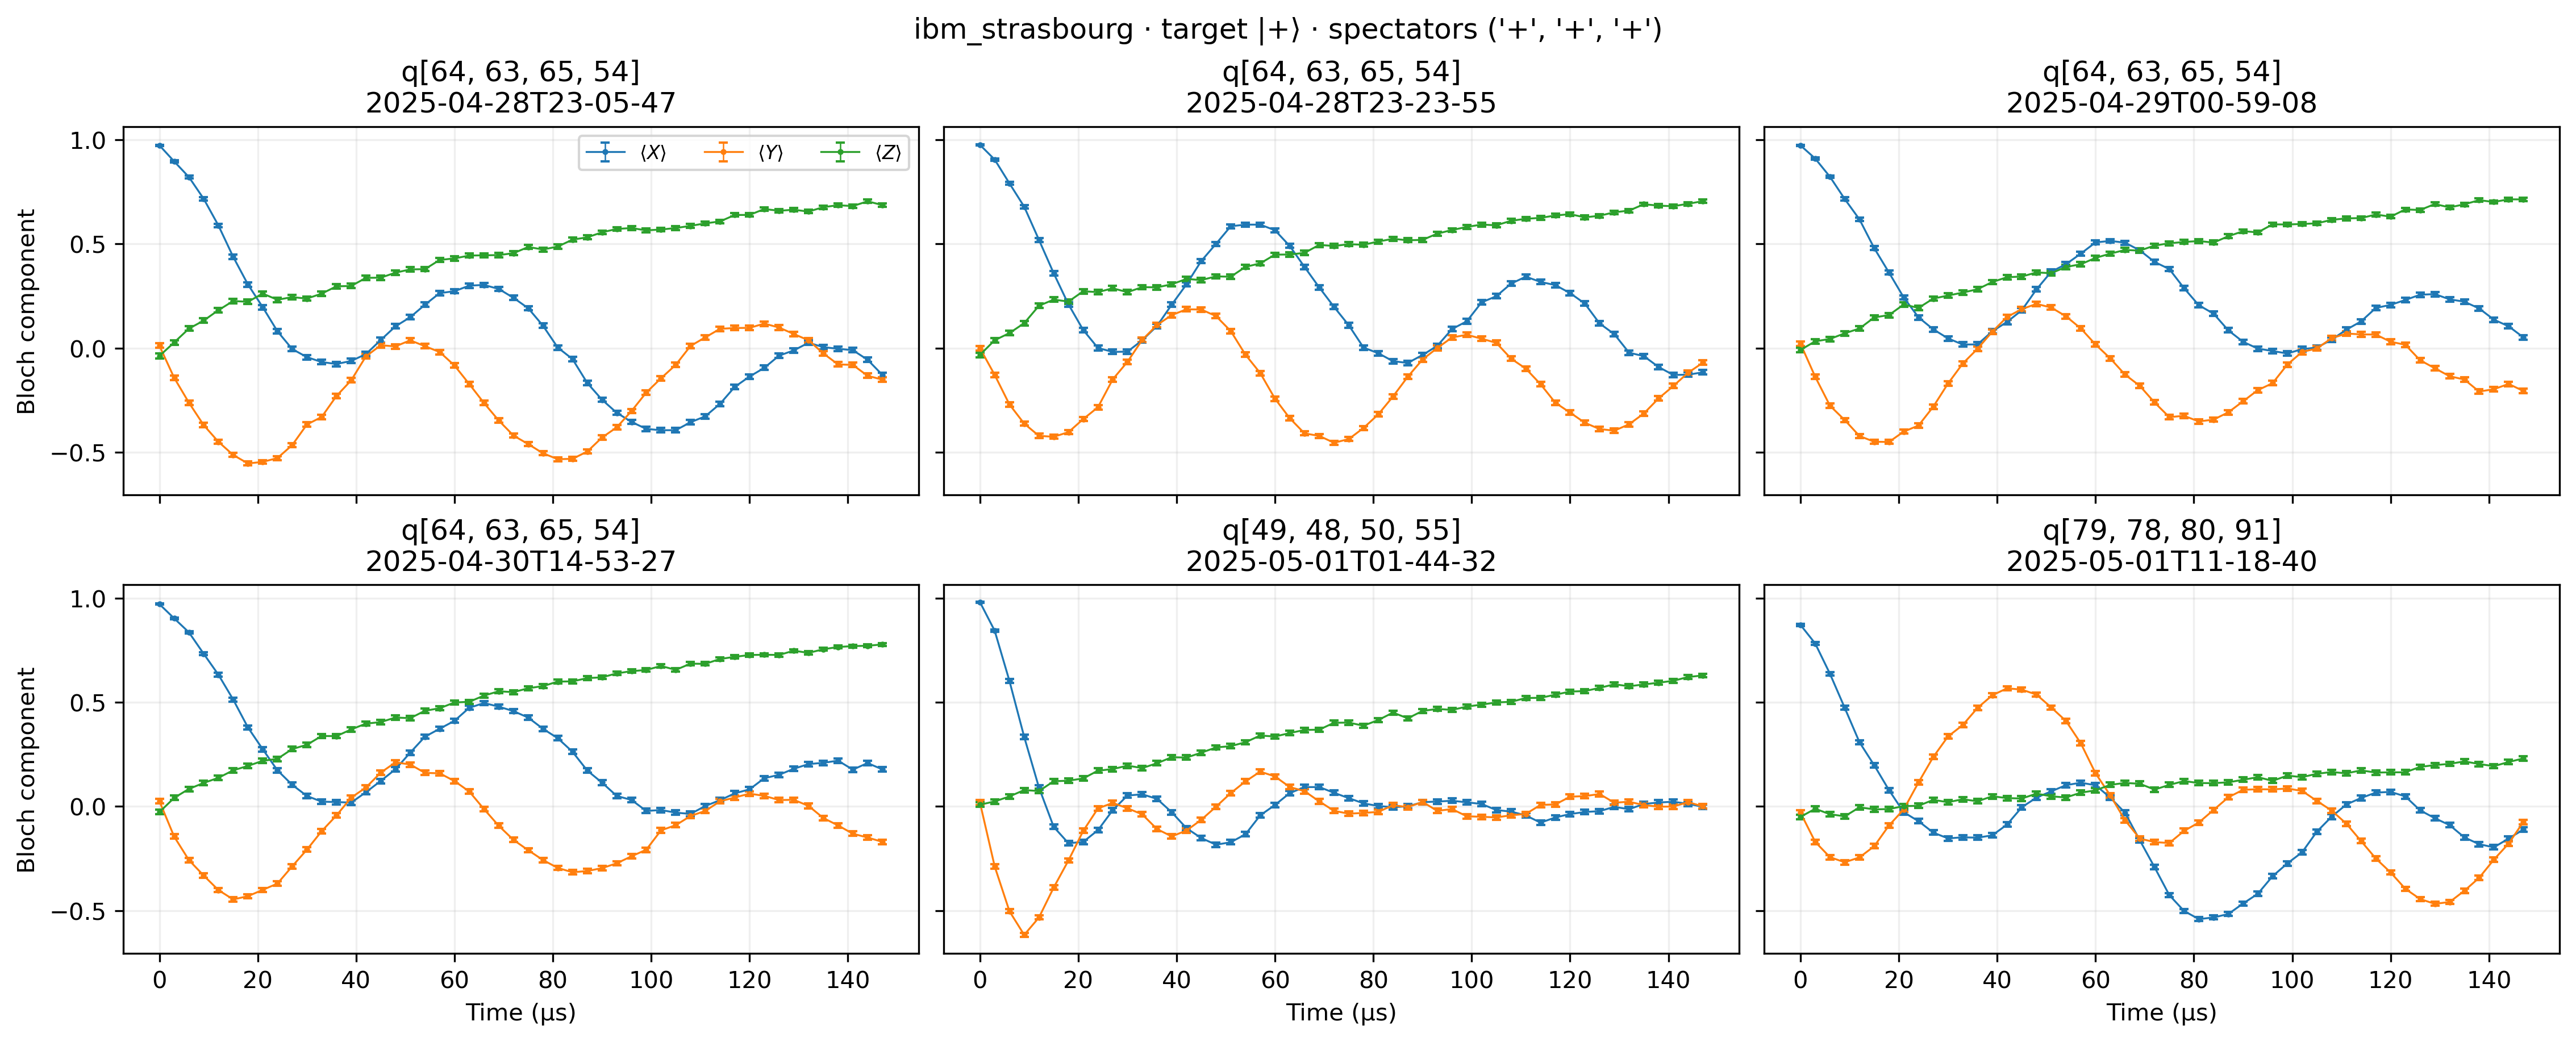

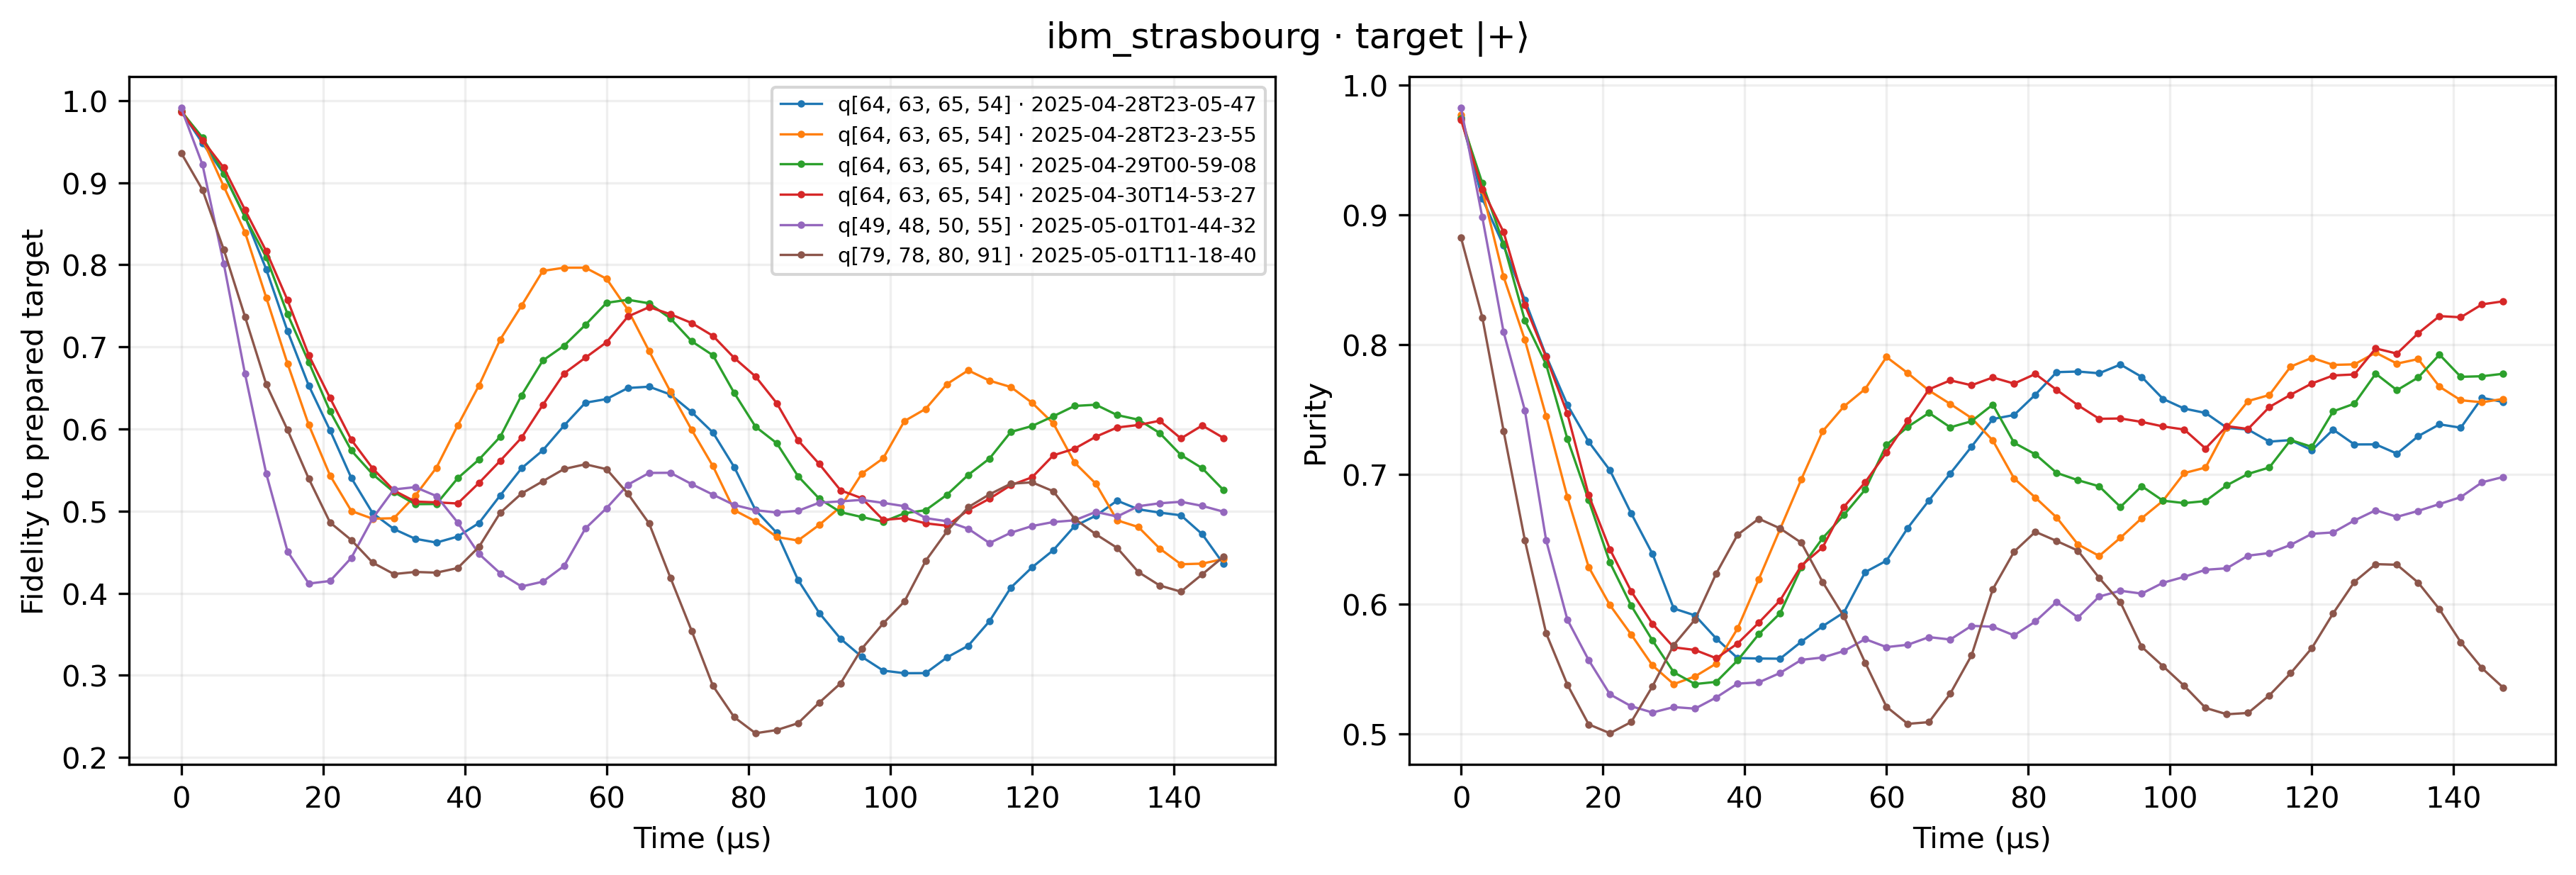

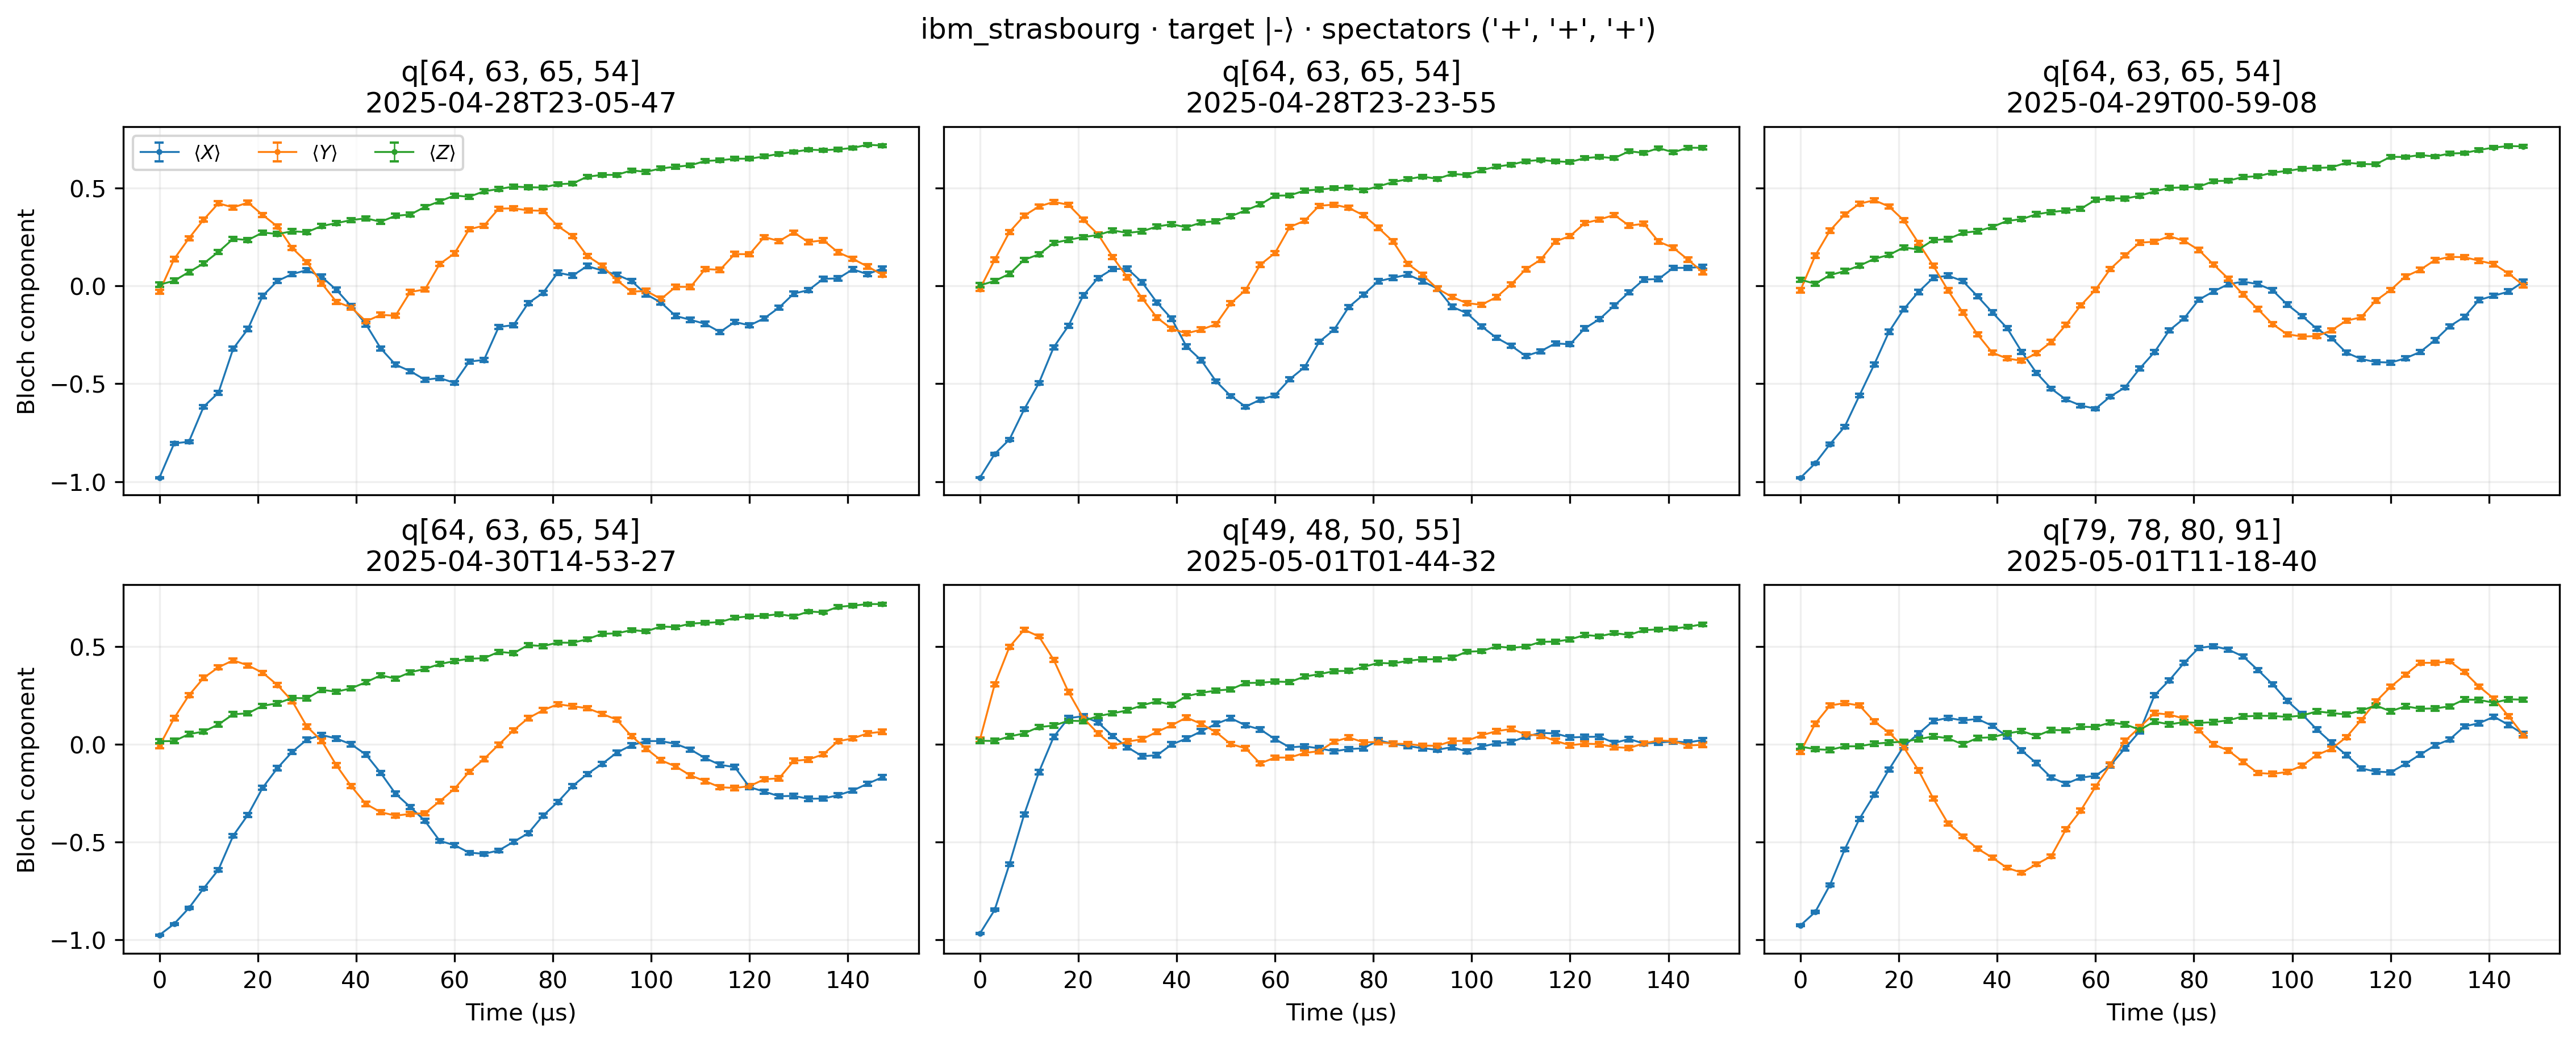

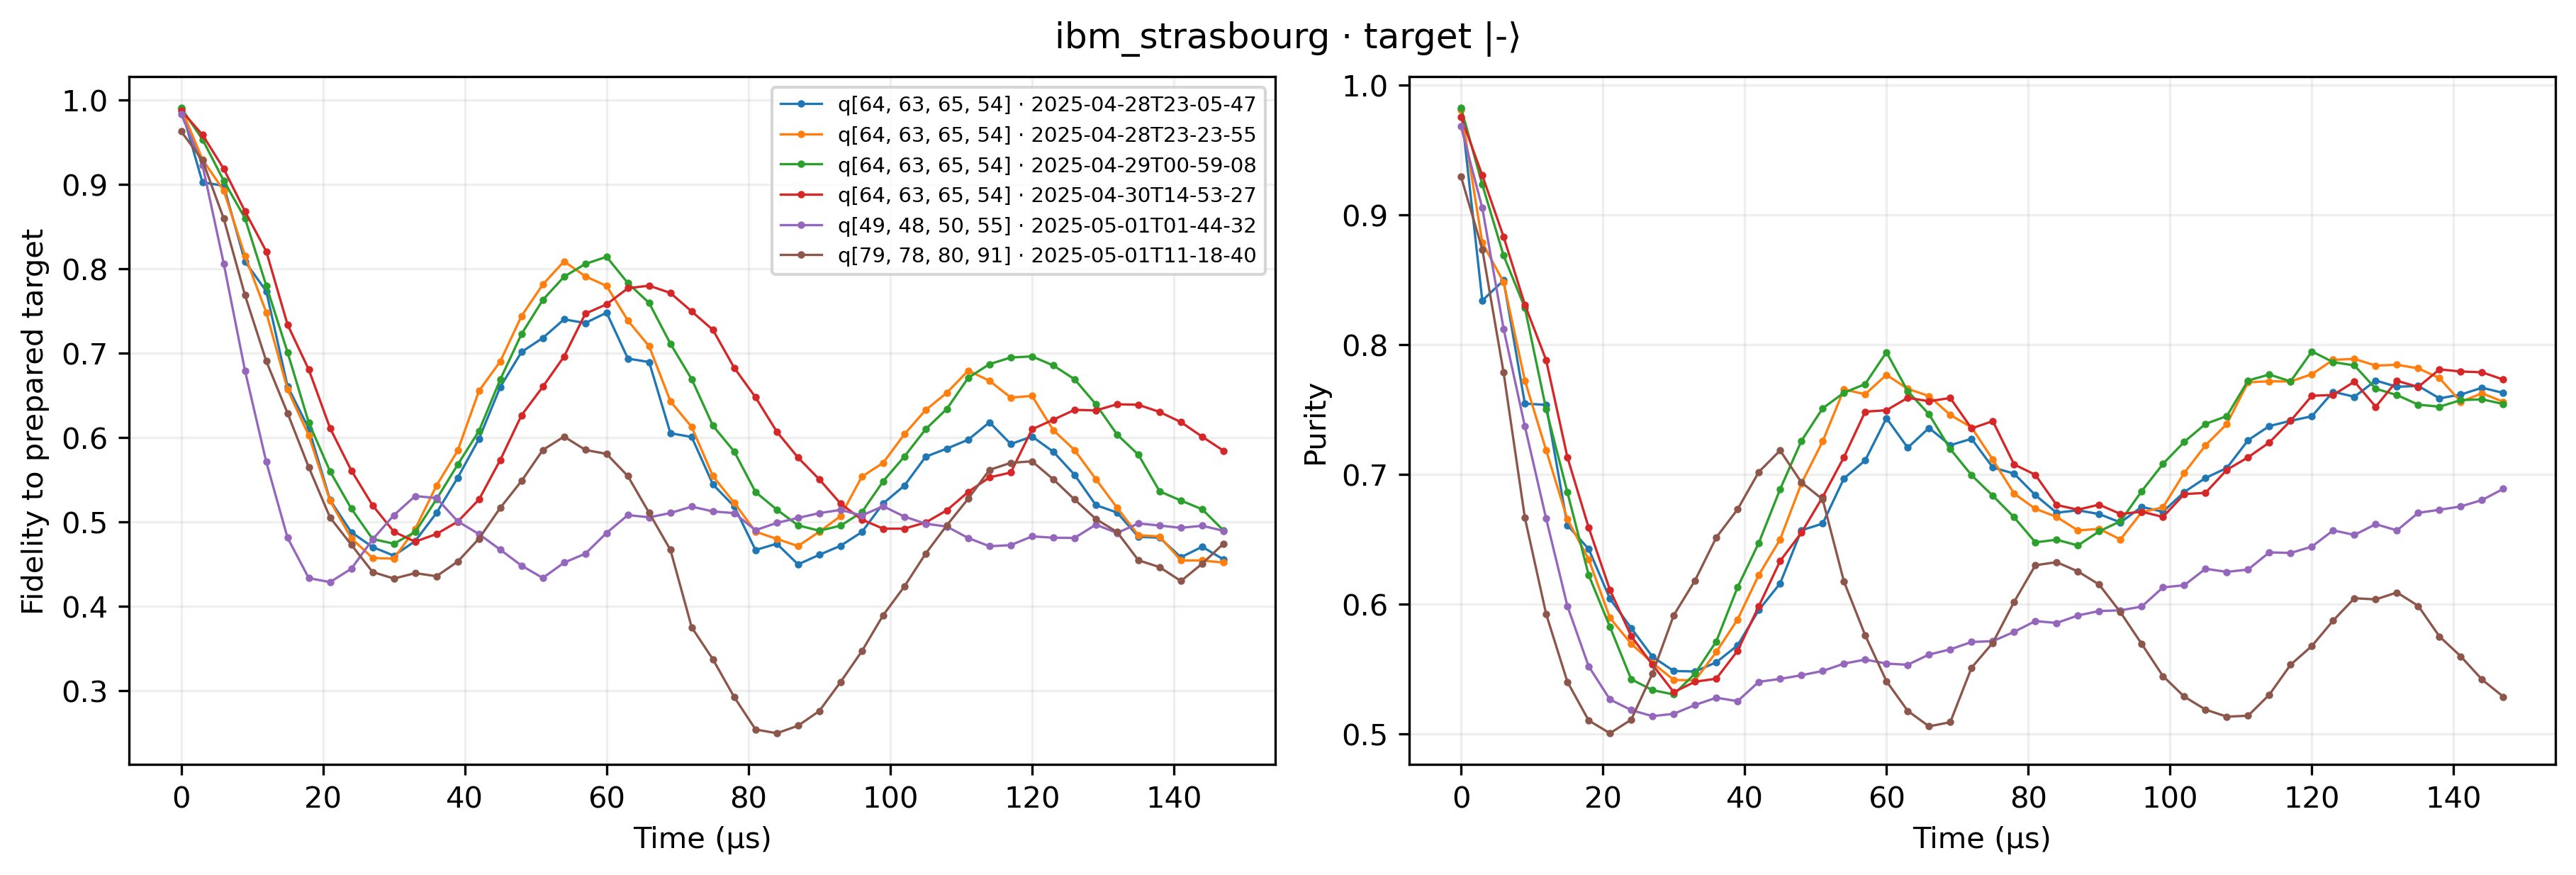

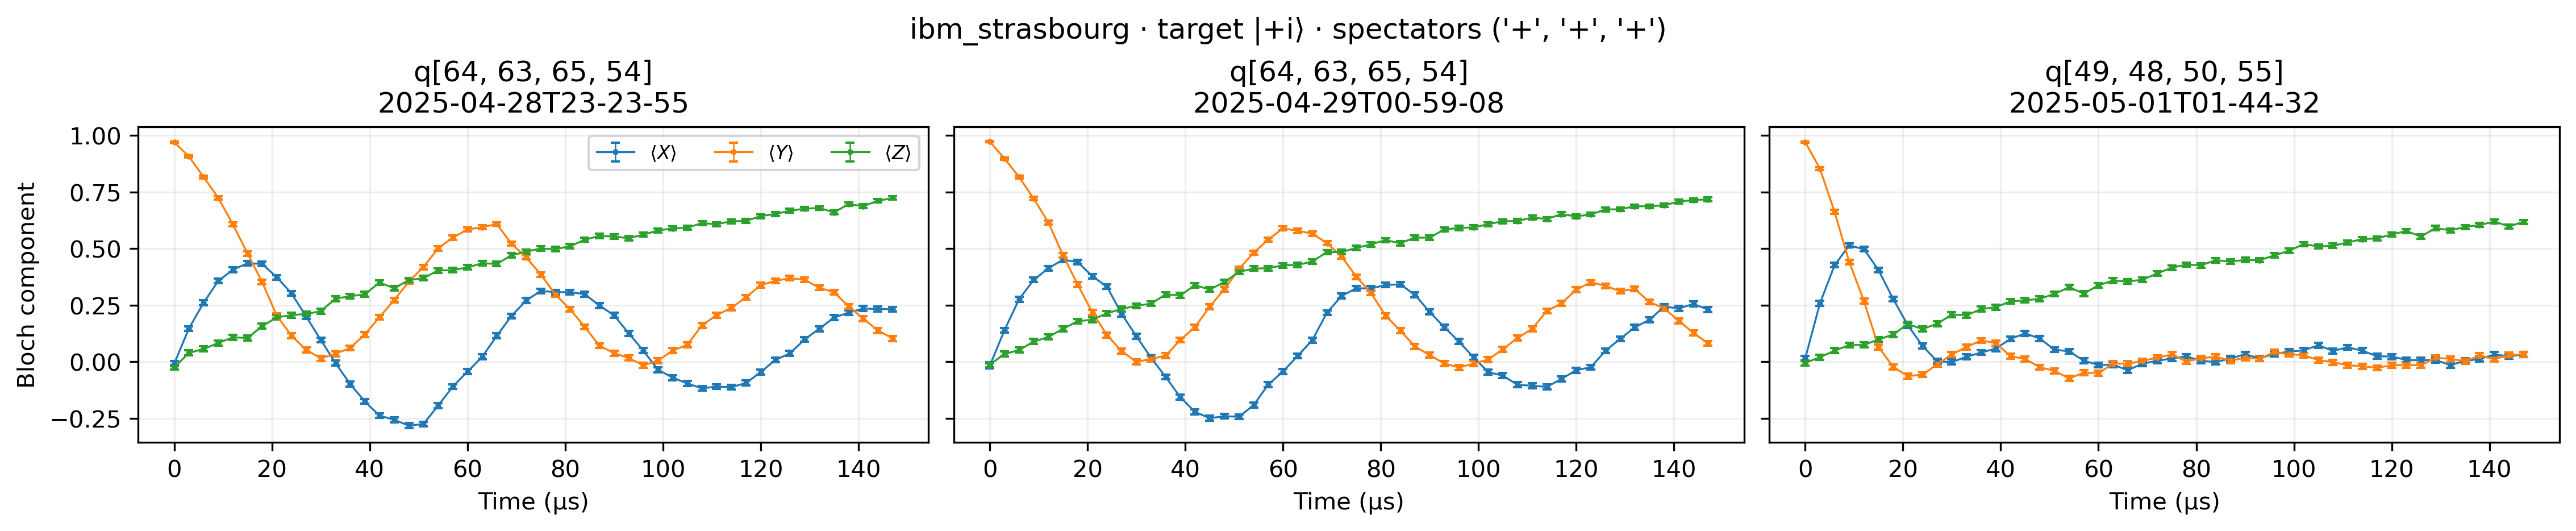

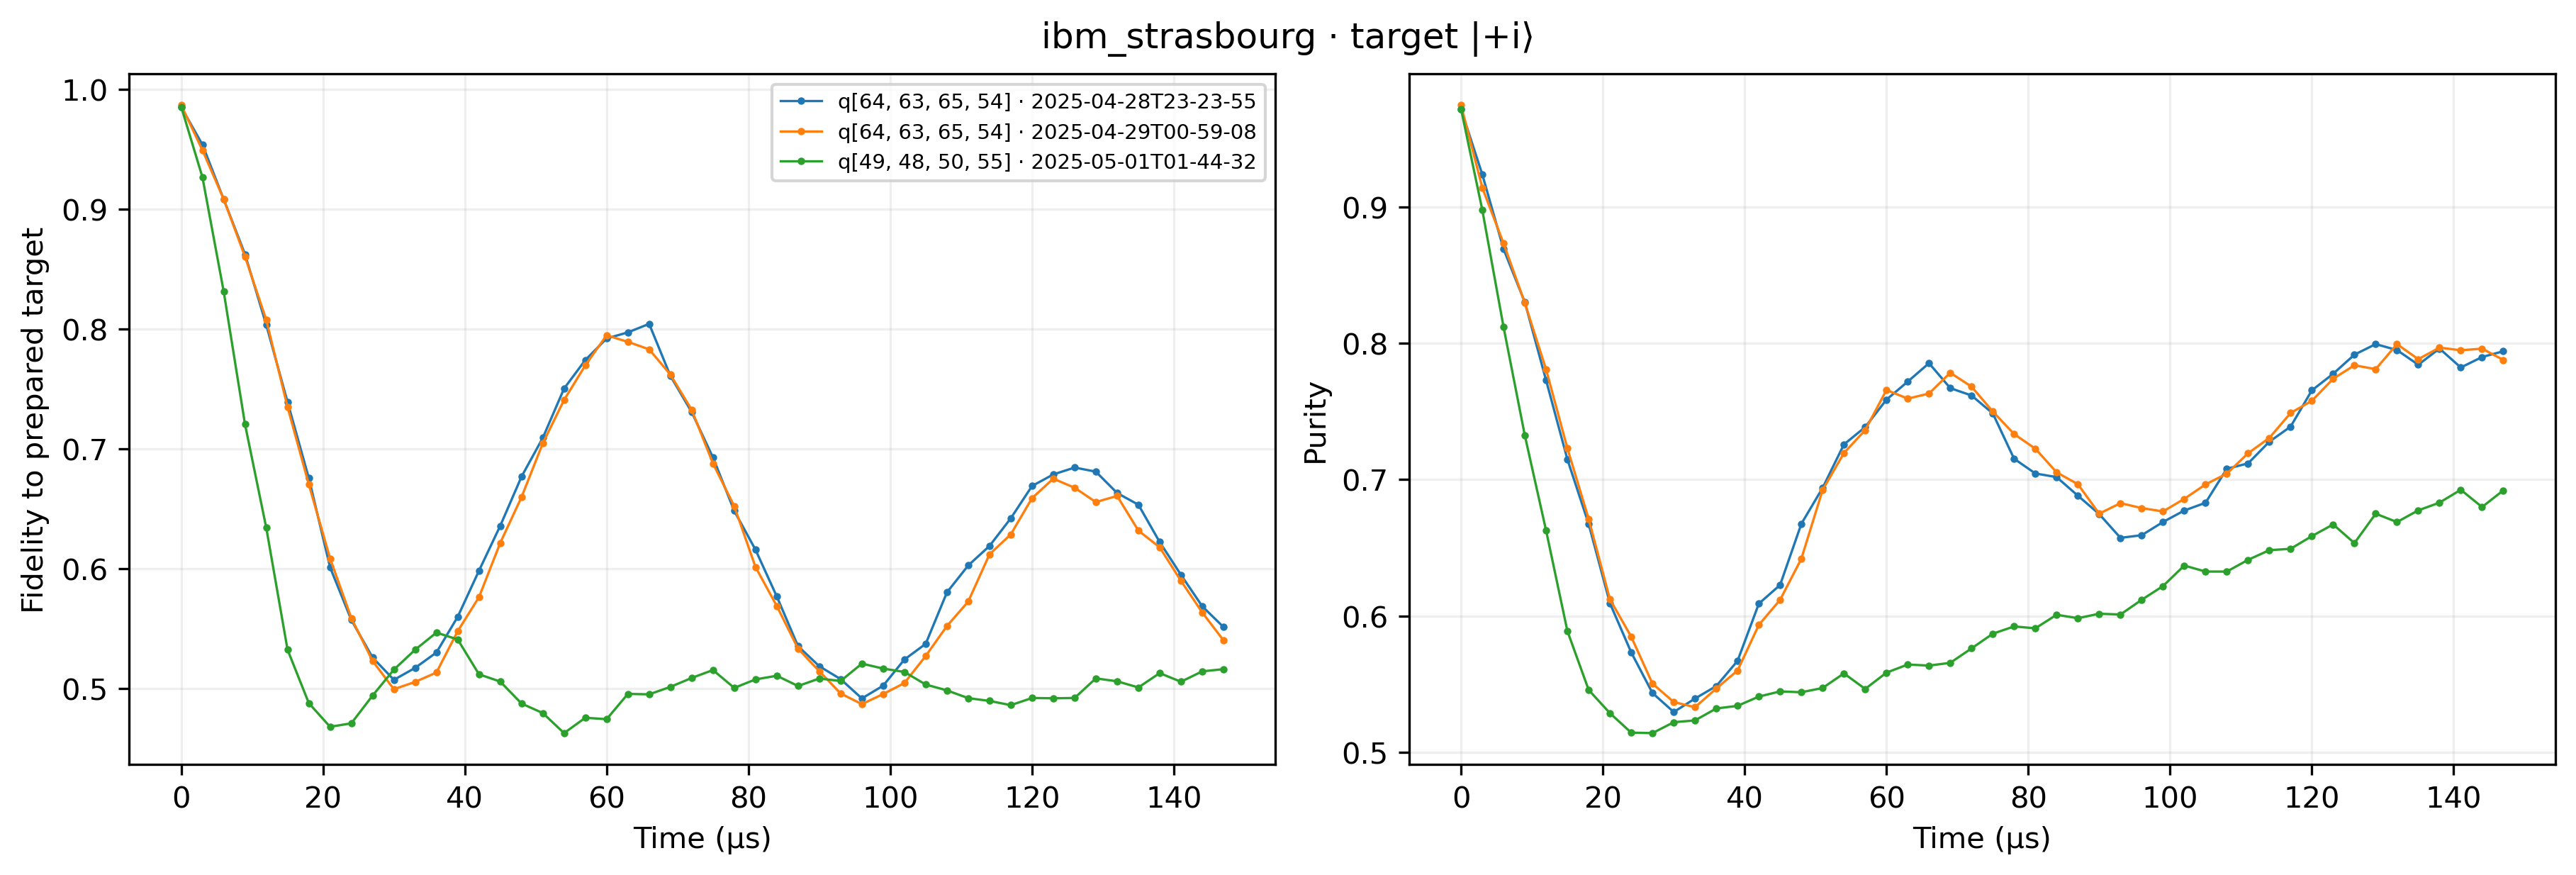

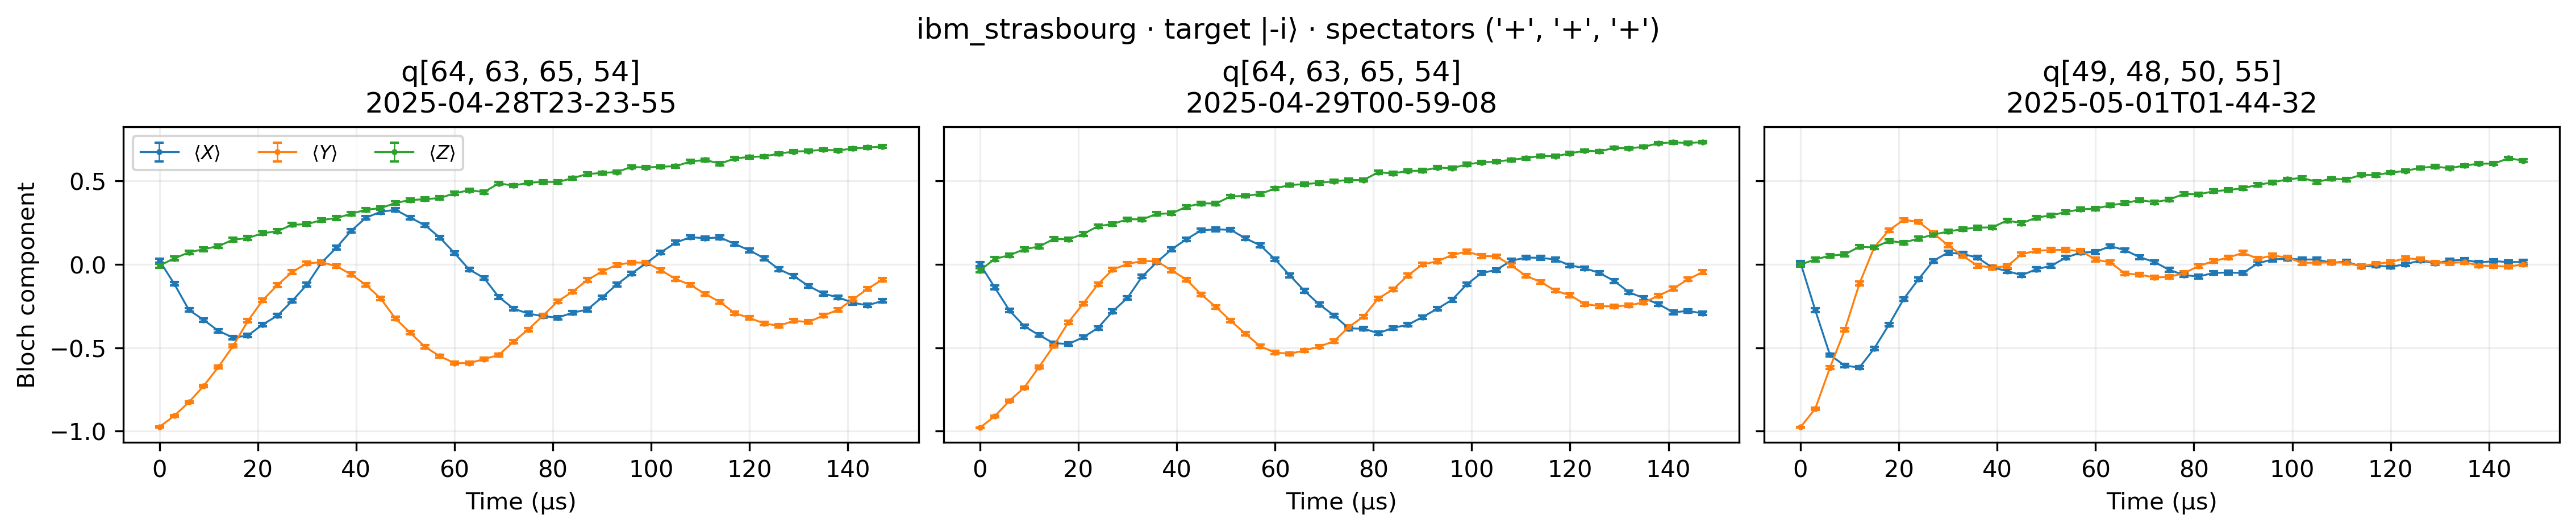

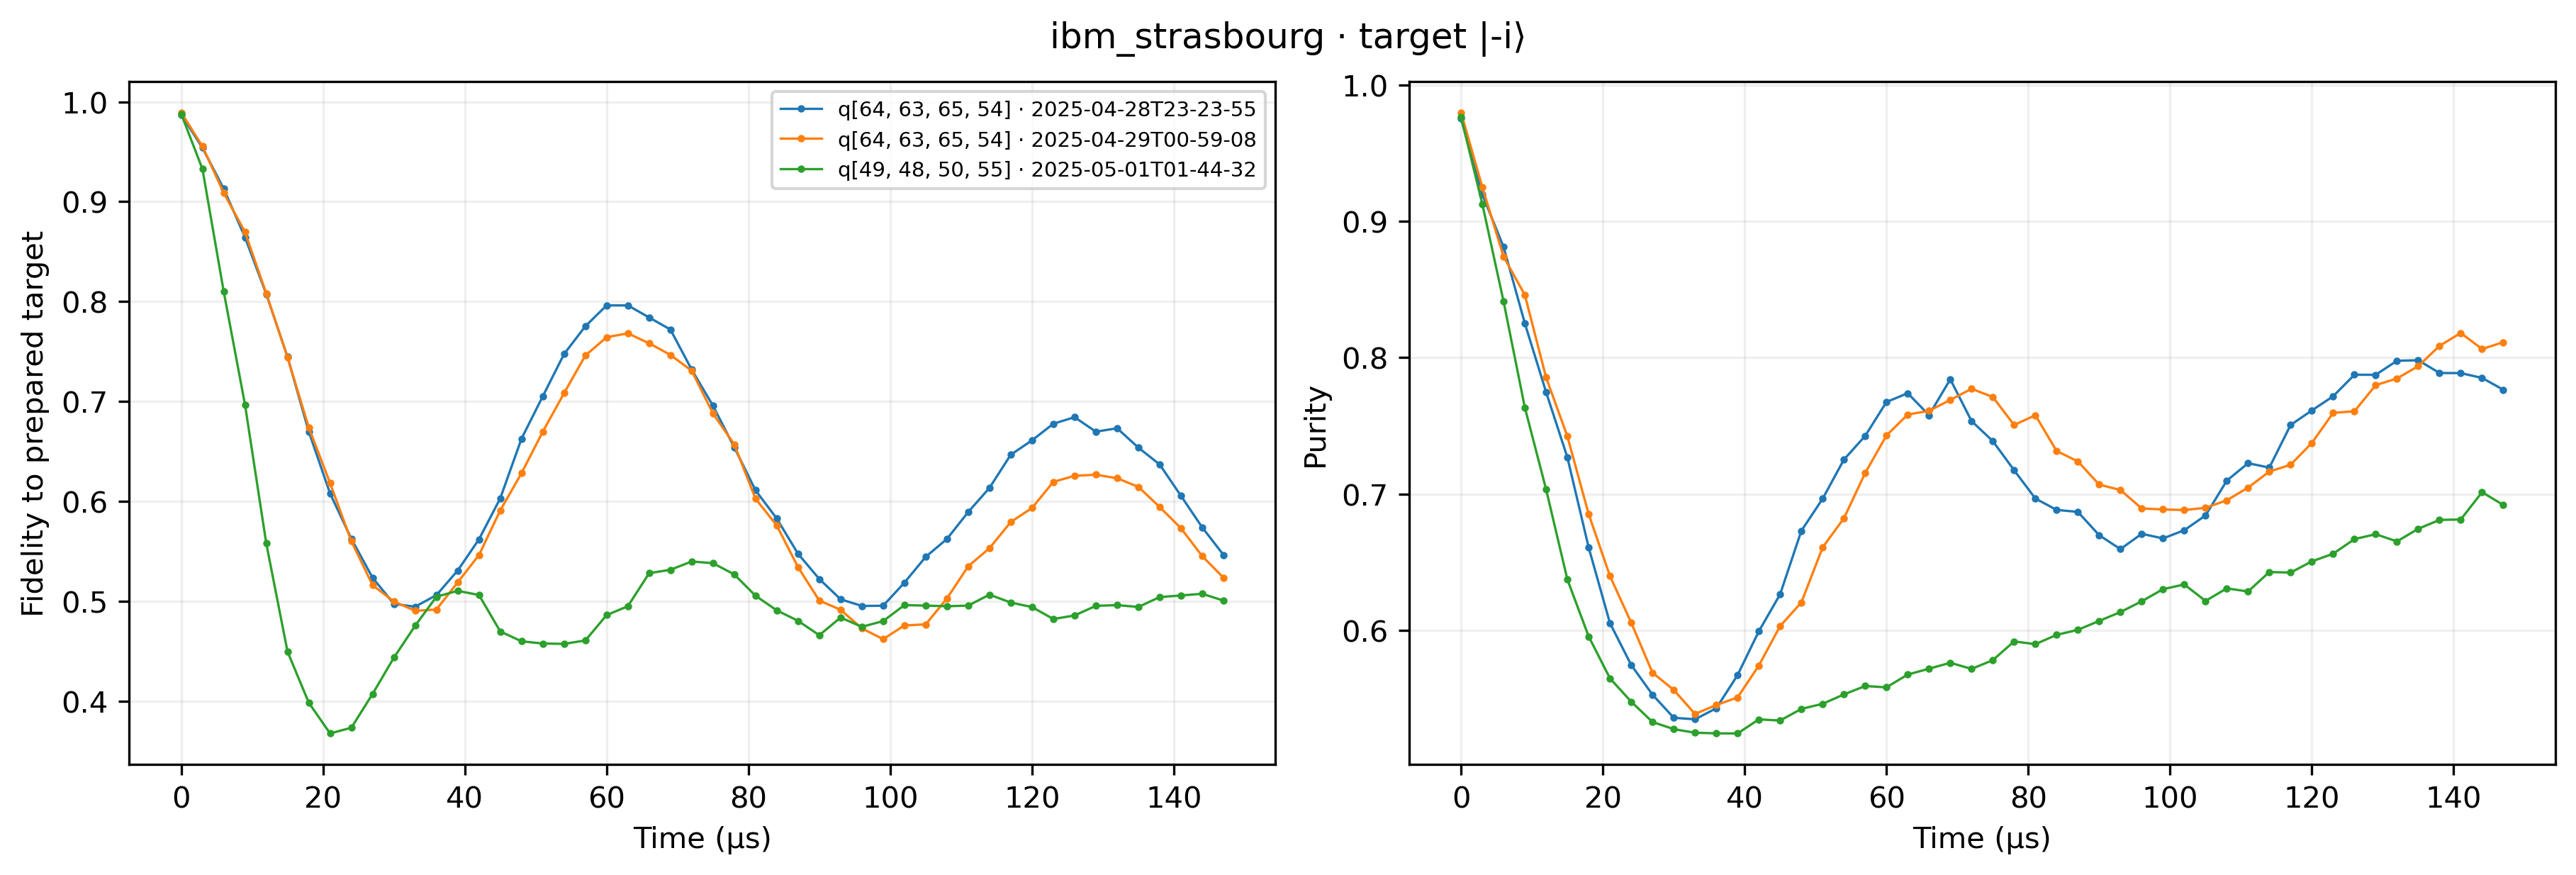

In [4]:
for state, selected in by_state.items():
    if not selected:
        print(f'No matching data for |{state}⟩.')
        continue
    plot_bloch(selected)
    plot_state_metrics(selected)


## Opposite-state comparisons

Pairs must share the run timestamp, ordered qubit list, spectator states, acquisition settings, and time grid. Missing partners are reported.

Trace distance is $T(\rho,\sigma)=|\mathbf r-\mathbf s|/2$. Directed quantum relative entropy is $D(\rho\Vert\sigma)=\mathrm{Tr}[\rho(\log_2\rho-\log_2\sigma)]$ in bits. The eigendecomposition below treats eigenvalues at or below $10^{-12}$ as numerical zeros. If the support of $\rho$ extends outside that of $\sigma$, the result is $+\infty$; such points are reported rather than replaced by a finite logarithm cutoff.

In [5]:
def match_pairs(state1, state2):
    first = {run['key']: run for run in by_state.get(state1, [])}
    second = {run['key']: run for run in by_state.get(state2, [])}
    for key in sorted(first.keys() ^ second.keys()):
        print(f'Unmatched {state1}/{state2} run: {key[0]}, q{key[1]}')
    pairs = []
    for key in sorted(first.keys() & second.keys()):
        a, b = first[key], second[key]
        if not np.allclose(a['frame'].t_us, b['frame'].t_us, rtol=0, atol=1e-9):
            raise ValueError(f"Mismatched time grids: {a['path']} and {b['path']}")
        pairs.append((a, b))
    return pairs


def relative_entropy(r, s):
    pauli = np.array([[[0, 1], [1, 0]], [[0, -1j], [1j, 0]],
                      [[1, 0], [0, -1]]])
    rho = (np.eye(2) + np.einsum('ti,ijk->tjk', r, pauli)) / 2
    sigma = (np.eye(2) + np.einsum('ti,ijk->tjk', s, pauli)) / 2
    values = []
    for a, b in zip(rho, sigma):
        eig_a = np.linalg.eigvalsh(a)
        eig_b, vectors = np.linalg.eigh(b)
        weights = np.diag(vectors.conj().T @ a @ vectors).real
        positive_a, positive_b = eig_a > 1e-12, eig_b > 1e-12
        if weights[~positive_b].sum() > 1e-12:
            values.append(np.inf)
        else:
            value = (np.sum(eig_a[positive_a] * np.log2(eig_a[positive_a]))
                     - np.sum(weights[positive_b] * np.log2(eig_b[positive_b])))
            values.append(max(0., float(value)))  # Remove negative roundoff.
    return np.asarray(values)


def plot_pairs(state1, state2, quantity='trace_distance'):
    if quantity not in ('trace_distance', 'relative_entropy'):
        raise ValueError('Choose trace_distance or relative_entropy.')
    pairs = match_pairs(state1, state2)
    if not pairs:
        print(f'No matching pairs for {state1}/{state2}.')
        return
    fig, ax = plt.subplots(figsize=(10, 4), layout='constrained')
    infinite_count = 0
    for a, b in pairs:
        r, s = state_bloch(a), state_bloch(b)
        values = (np.linalg.norm(r - s, axis=1) / 2 if quantity == 'trace_distance'
                  else relative_entropy(r, s))
        finite = np.isfinite(values)
        if not finite.all():
            infinite_count += np.count_nonzero(~finite)
            print(f"Infinite relative entropy for {a['label']} at t_us={a['frame'].t_us.to_numpy()[~finite]}")
        ax.plot(a['frame'].t_us, np.where(finite, values, np.nan), '.-',
                markersize=3, linewidth=0.8, label=a['label'])
    ylabel = 'Trace distance' if quantity == 'trace_distance' else 'Relative entropy (bits)'
    ax.set(xlabel='Time (µs)', ylabel=ylabel,
           title=f'{BACKEND} · {quantity.replace("_", " ")} · |{state1}⟩, |{state2}⟩')
    if infinite_count:
        ax.text(0.02, 0.02, f'{infinite_count} infinite values; times listed above', transform=ax.transAxes)
    ax.legend(fontsize=8)
    plt.show()
    return fig


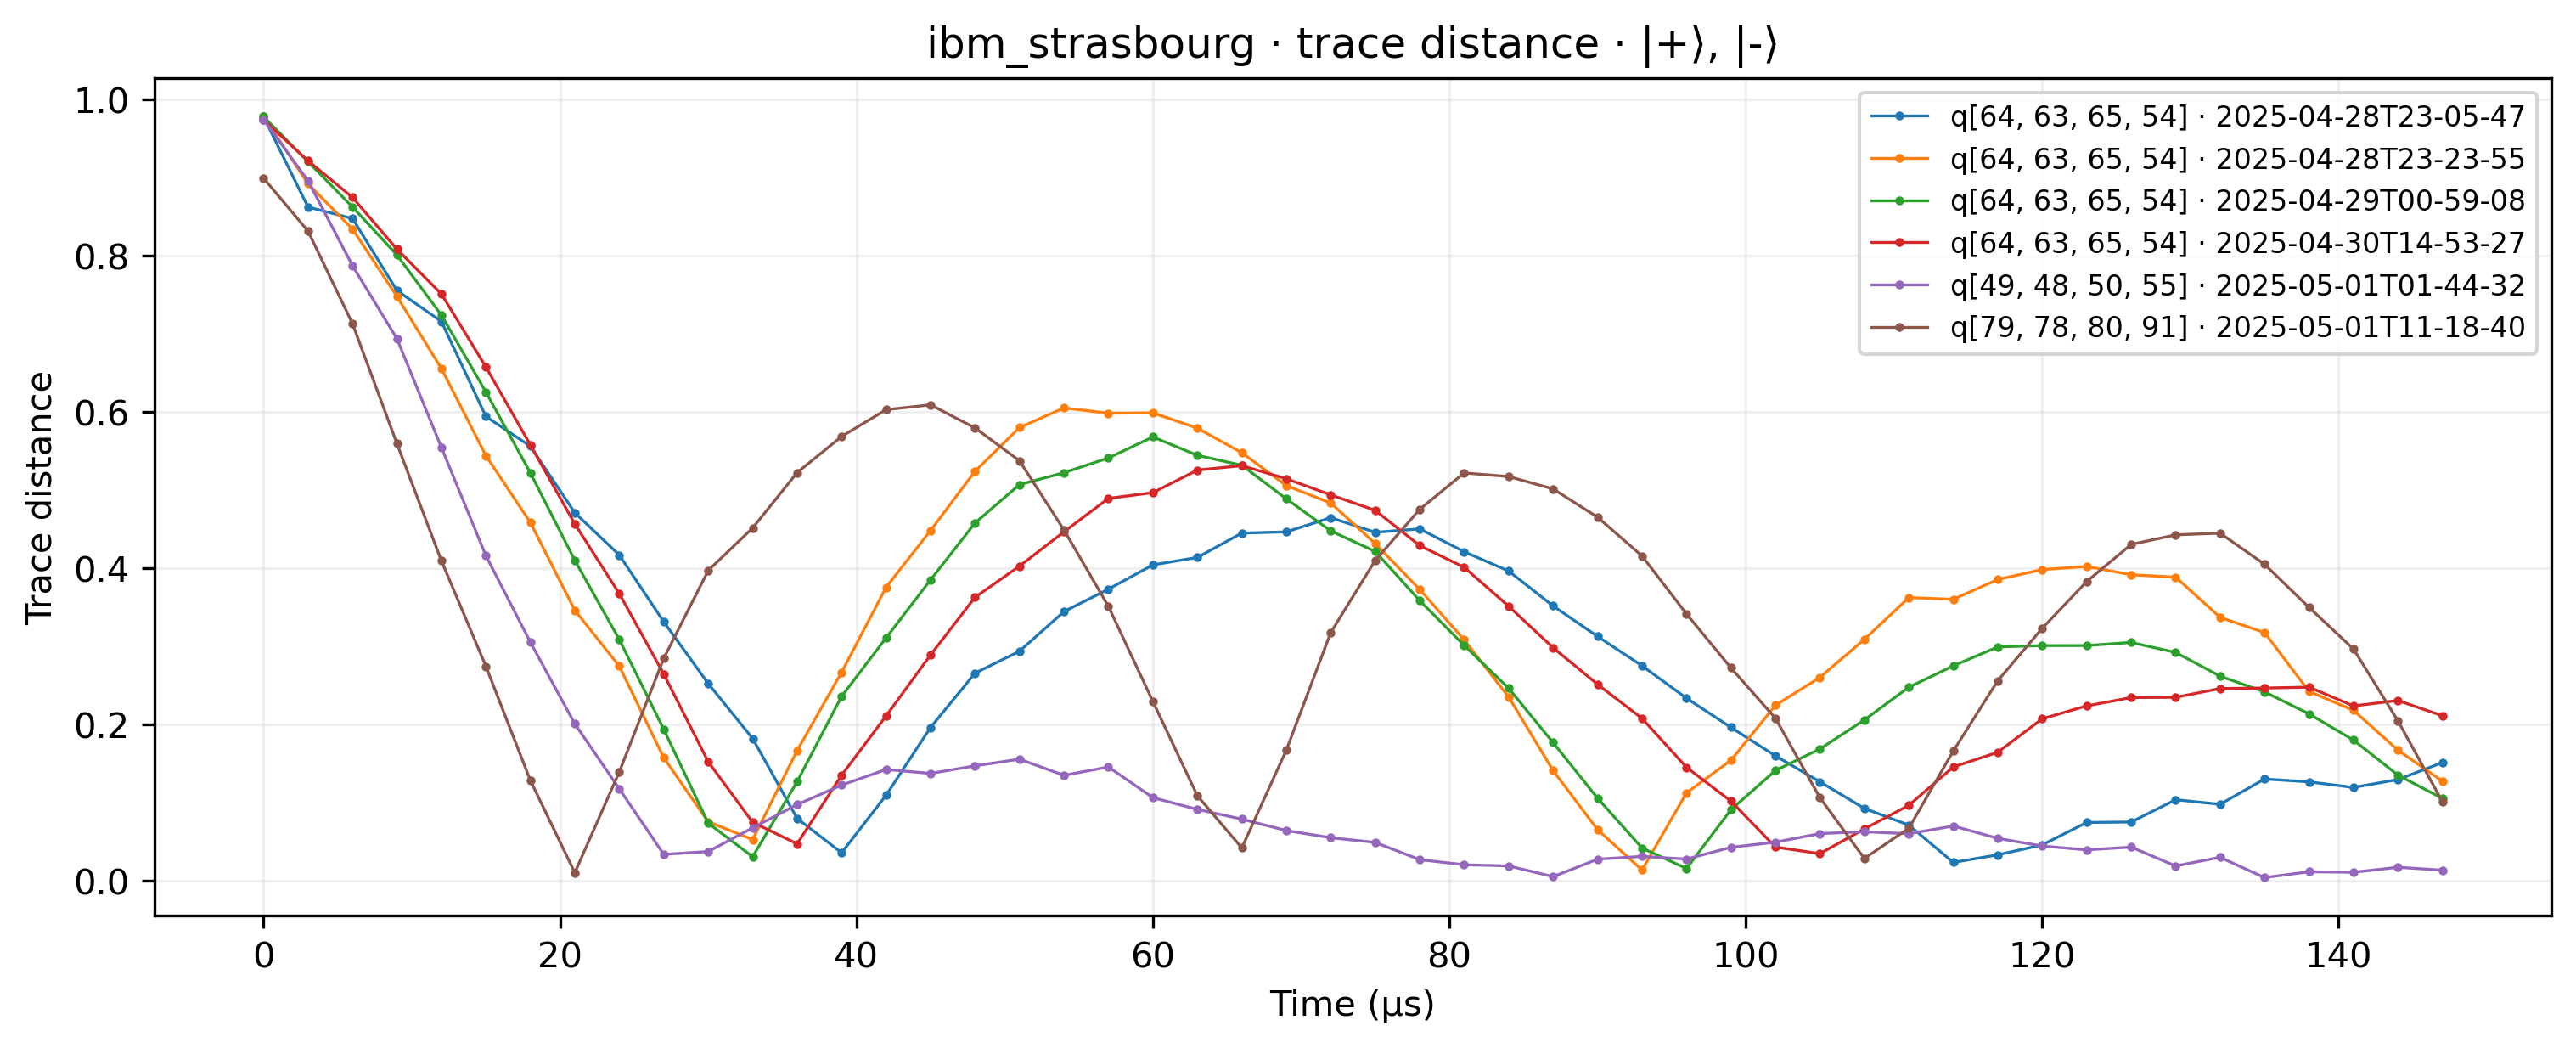

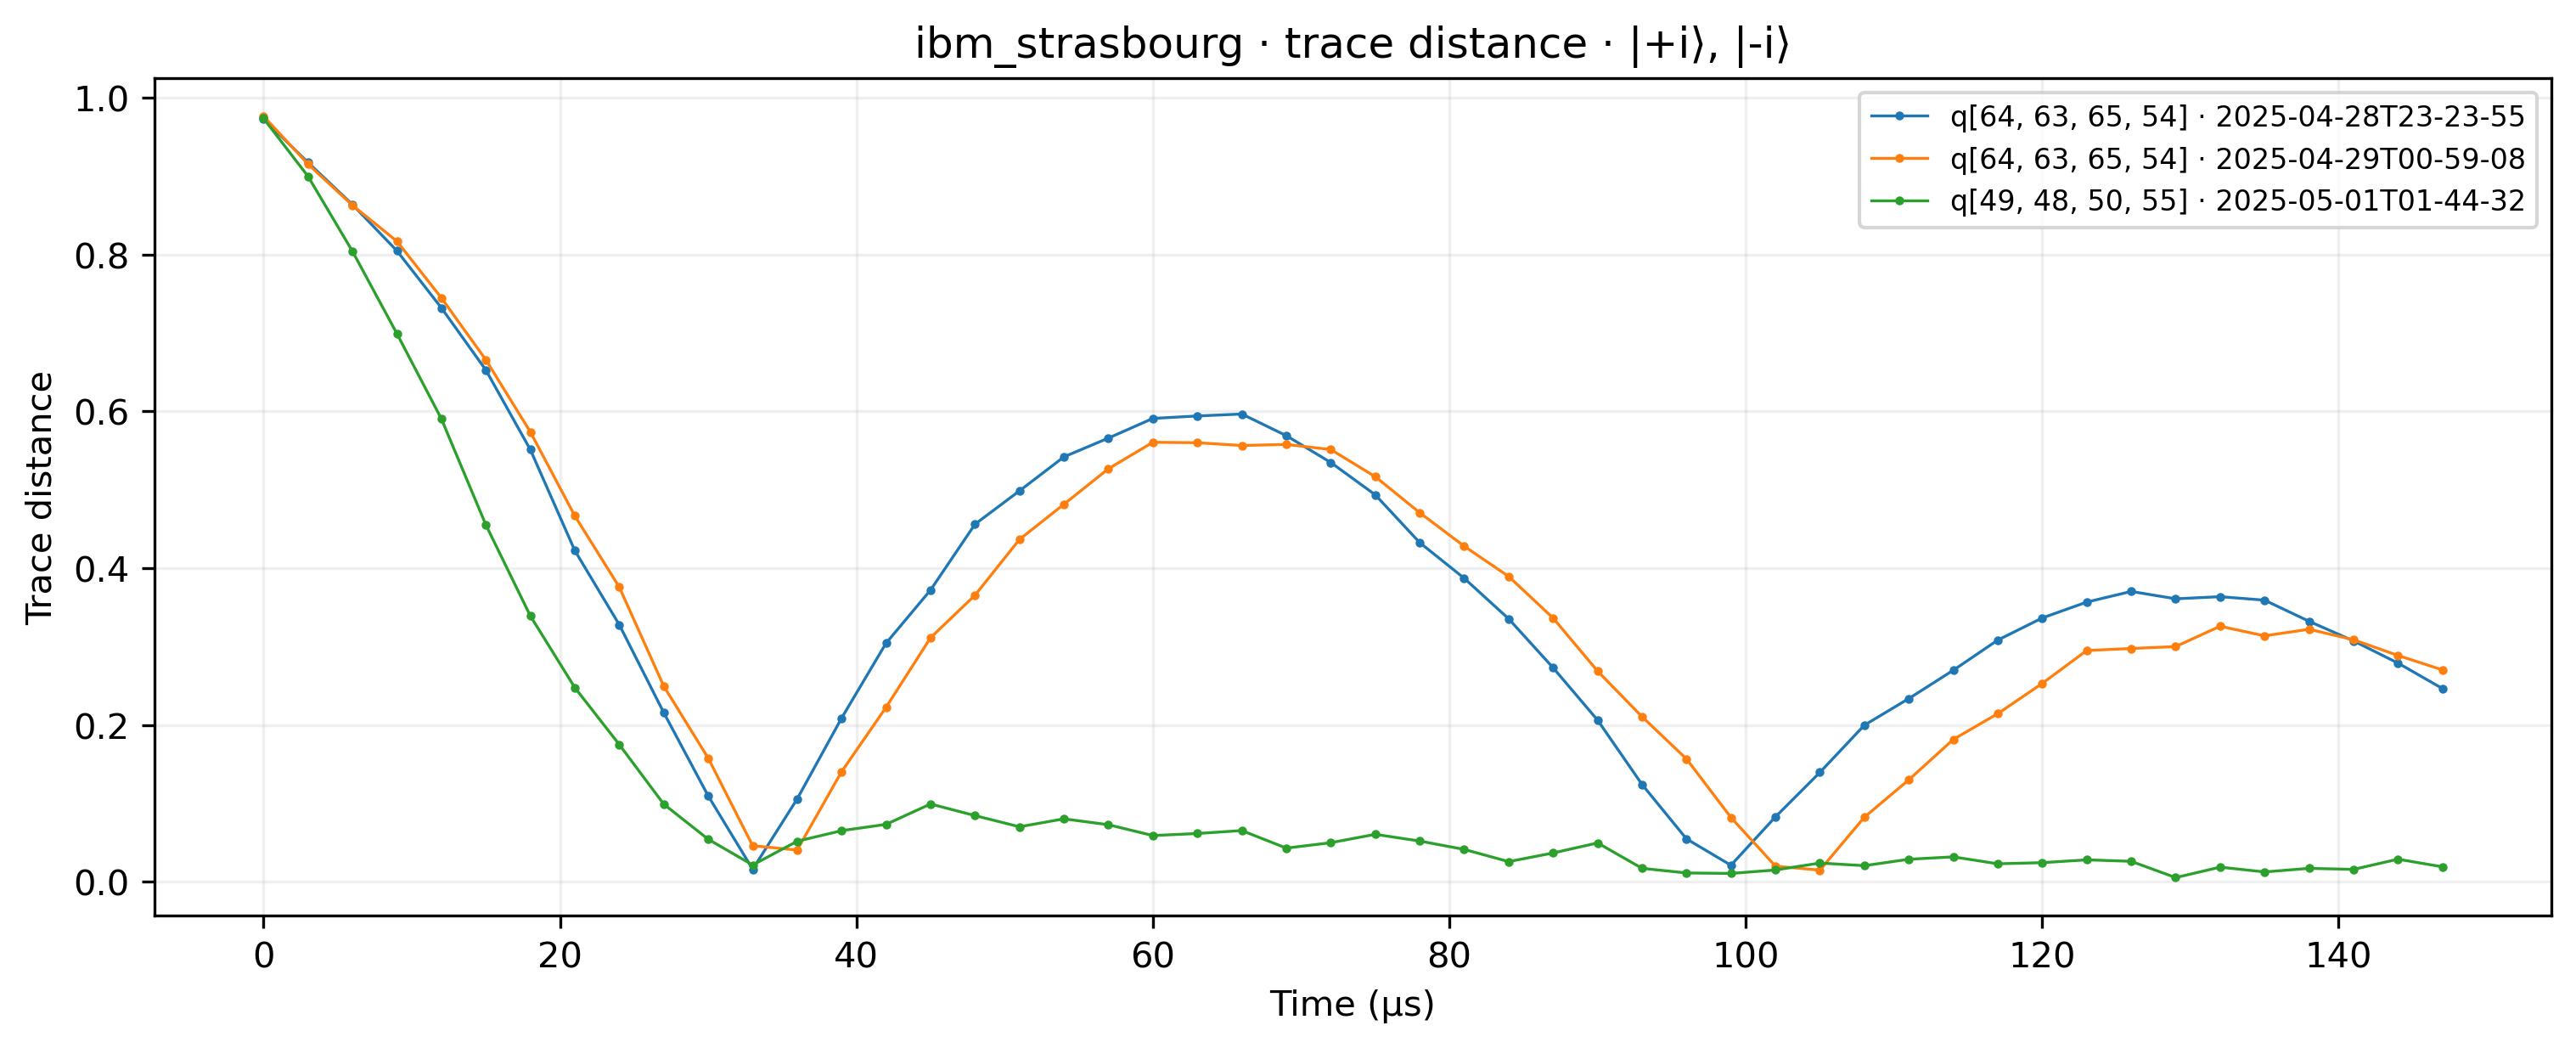

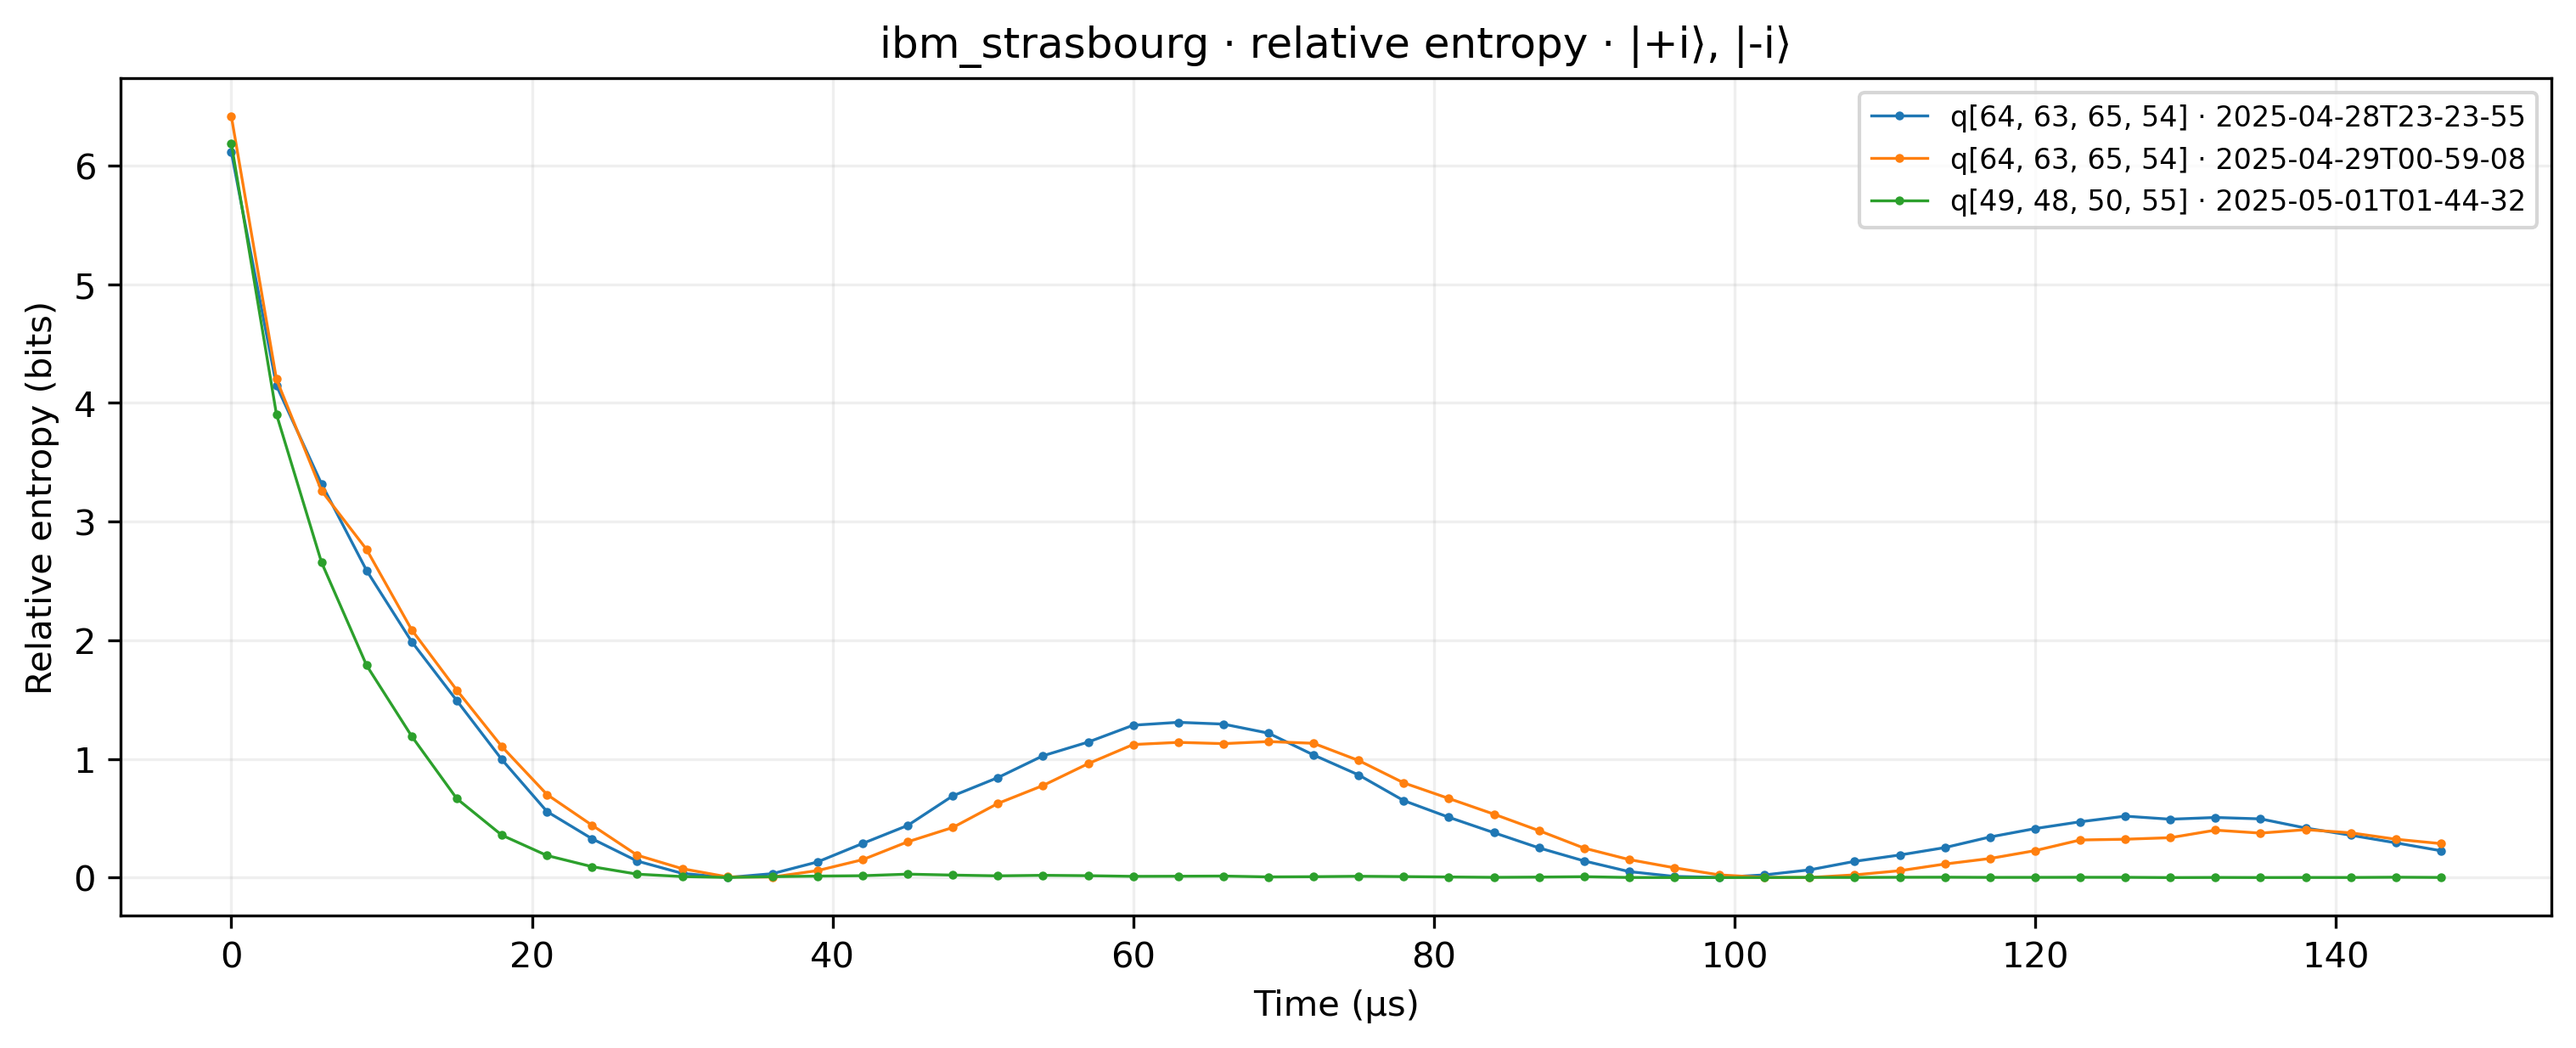

In [6]:
plot_pairs('+', '-');
plot_pairs('+i', '-i');
plot_pairs('+i', '-i', quantity='relative_entropy');
